In [11]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import random
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from main.utils import data_manage_utils, train_utils

importlib.reload(train_utils)
importlib.reload(data_manage_utils)

loading_folder = "2024_06_17-0642"
loading_spec = "RF"

ROOT_PATH = os.path.abspath("../../../")
TRAIN_DATA_FOLDER = os.path.join(ROOT_PATH, "data/training/training_results/", loading_spec, loading_folder)

# Finding corresponding prep data folder
settings_path = os.path.join(TRAIN_DATA_FOLDER, "estimation_settings.json")
PREP_DATA_FOLDER = data_manage_utils.find_data_path_by_settings_file(settings_path,ROOT_PATH)

In [12]:
pert_result_df_path = os.path.join(TRAIN_DATA_FOLDER,"pert_out_df.pkl.gz")

pert_df = pd.read_pickle(pert_result_df_path, compression="gzip")

pert_cols = list(set(pert_df.columns) - {"ARR_MIN_OF_DAY_COS", "ARR_MIN_OF_DAY_SIN", "ARR_DAY_SIN", "ARR_DAY_COS"})
USE_TH = False
if USE_TH:
    pert_cols = ["TEMP(C)","WIND_SPEED(KMH)","REL_HUMIDITY(PERCENT)","WIND_DRCT(DEG)", "SEA_LEVEL_PRESSURE(MILLIBAR)"]

pert_df

,DEP_DELAY(MINS),CRS_ELAPSED_TIME(MINS),NR_PREV_ARR_FLIGHTS(1HR),ARR_DAY_SIN,ARR_DAY_COS,ARR_MIN_OF_DAY_SIN,ARR_MIN_OF_DAY_COS,APPROACH_SPEED(KMH),TAIL_HEIGHT(M),PARKING_AREA(SQM),...,EVENT_HZ,EVENT_IC,EVENT_RA,EVENT_SN,EVENT_TS,RUNWAY_ERROR(PERC),y_true,pert_id,level,y
0,77.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
1,62.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
2,66.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
3,70.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
4,73.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10501874,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.78,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501875,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.82,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501876,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.85,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501877,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.88,0,RUNWAY_ERROR(PERC)<6600848>,3,1


In [13]:
pert_test_rf = pd.read_pickle("../pert_test_results_rf.pkl")
pert_test_adab = pd.read_pickle("../pert_test_results_adab.pkl")
pert_test_xgb = pd.read_pickle("../pert_test_results_xgb.pkl")

In [14]:
pert_test_xgb

,y_true,y,pert_alarm,y_outcomes,changed_to,corrected,worsened,correct,y_corrected,y_forced_mistake,y_forced_correction
idx,,,,,,,,,,,
10001243,1,1,False,{1},{},0.0,0.000000,True,1,1,1
10003947,1,1,False,{1},{},0.0,0.000000,True,1,1,1
10004727,1,1,False,{1},{},0.0,0.000000,True,1,1,1
10006126,1,1,False,{1},{},0.0,0.000000,True,1,1,1
10006791,1,1,False,{1},{},0.0,0.000000,True,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9998396,0,0,False,{0},{},0.0,0.000000,True,0,0,0
9998430,2,2,False,{2},{},0.0,0.000000,True,2,2,2
9998460,1,1,False,{1},{},0.0,0.000000,True,1,1,1


In [15]:
alarmed_rf = pert_test_rf[pert_test_rf["pert_alarm"]]
reduced_rf = pert_test_rf[~pert_test_rf["pert_alarm"]]
alarmed_adab = pert_test_adab[pert_test_adab["pert_alarm"]]
reduced_adab = pert_test_adab[~pert_test_adab["pert_alarm"]]
alarmed_xgb = pert_test_xgb[pert_test_xgb["pert_alarm"]]
reduced_xgb = pert_test_xgb[~pert_test_xgb["pert_alarm"]]

In [16]:
alarmed_rf

,y_true,y,pert_alarm,y_outcomes,changed_to,corrected,worsened,correct,y_corrected,y_forced_mistake,y_forced_correction
idx,,,,,,,,,,,
10012474,1,2,True,"{1, 2}",{1},0.032258,0.000000,False,1,2,2
10026093,1,0,True,"{0, 1}",{1},0.225806,0.000000,False,1,0,0
10032433,1,1,True,"{0, 1}",{0},0.000000,0.032258,True,1,1,1
10033431,2,2,True,"{1, 2}",{1},0.000000,0.129032,True,2,2,2
10035655,1,1,True,"{0, 1}",{0},0.000000,0.032258,True,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9995297,1,0,True,"{0, 1}",{1},0.032258,0.000000,False,1,0,0
9996537,0,0,True,"{0, 1}",{1},0.000000,0.032258,True,0,0,0
9997432,1,0,True,"{0, 1}",{1},0.032258,0.000000,False,1,0,0


In [17]:
def perc_to_rounded(val):
    return round(val*100, ndigits=2)

def calc_prec(y_true, y_pred, label):
    y_pred_filtered = [1 if v == label else 0 for v in y_pred]
    y_true_filtered = [1 if v == label else 0 for v in y_true]
    return perc_to_rounded(precision_score(y_true=y_true_filtered, y_pred=y_pred_filtered))
    
def calc_metric_dict(data_dict):
    model_types = ["rf", "adab", "xgb"]
    final_result_dict = {
            "rf": {},
            "adab": {},
            "xgb": {}
        }
    for model_t in model_types:
        ss_data_dict = data_dict.get(model_t)
        ss_types = ["original", "alarmed", "filtered"]
        type_result_dict = {
            "original": {},
            "alarmed": {},
            "filtered": {}
        }
        for ss in ss_types:
            data = ss_data_dict.get(ss)
            output_dict = {
                "acc": perc_to_rounded(accuracy_score(y_true=data["y_true"], y_pred=data["y"])),
                "p0": calc_prec(y_true=data["y_true"], y_pred=data["y"], label=0),
                "p1": calc_prec(y_true=data["y_true"], y_pred=data["y"], label=1),
                "p2": calc_prec(y_true=data["y_true"], y_pred=data["y"], label=2)
            }
            type_result_dict.update({ss:output_dict})
        final_result_dict.update({model_t:type_result_dict})
    return final_result_dict

data_dict = {
    "rf": {
        "original": pert_test_rf,
        "alarmed": alarmed_rf,
        "filtered" : reduced_rf
    },
    "adab":{
        "original": pert_test_adab,
        "alarmed": alarmed_adab,
        "filtered" : reduced_adab
    },
    "xgb": {
        "original": pert_test_xgb,
        "alarmed": alarmed_xgb,
        "filtered" : reduced_xgb
    }
}

metric_dict = calc_metric_dict(data_dict=data_dict)
metric_dict

{'rf': {'original': {'acc': 73.43, 'p0': 58.3, 'p1': 78.22, 'p2': 88.78},
  'alarmed': {'acc': 49.9, 'p0': 46.27, 'p1': 58.79, 'p2': 49.56},
  'filtered': {'acc': 76.34, 'p0': 62.31, 'p1': 79.27, 'p2': 90.77}},
 'adab': {'original': {'acc': 71.46, 'p0': 59.07, 'p1': 72.3, 'p2': 89.01},
  'alarmed': {'acc': 53.22, 'p0': 53.69, 'p1': 51.88, 'p2': 56.97},
  'filtered': {'acc': 75.37, 'p0': 66.22, 'p1': 74.19, 'p2': 91.59}},
 'xgb': {'original': {'acc': 75.19, 'p0': 65.86, 'p1': 75.88, 'p2': 89.5},
  'alarmed': {'acc': 55.95, 'p0': 57.2, 'p1': 55.41, 'p2': 50.08},
  'filtered': {'acc': 80.07, 'p0': 72.32, 'p1': 79.46, 'p2': 93.59}}}

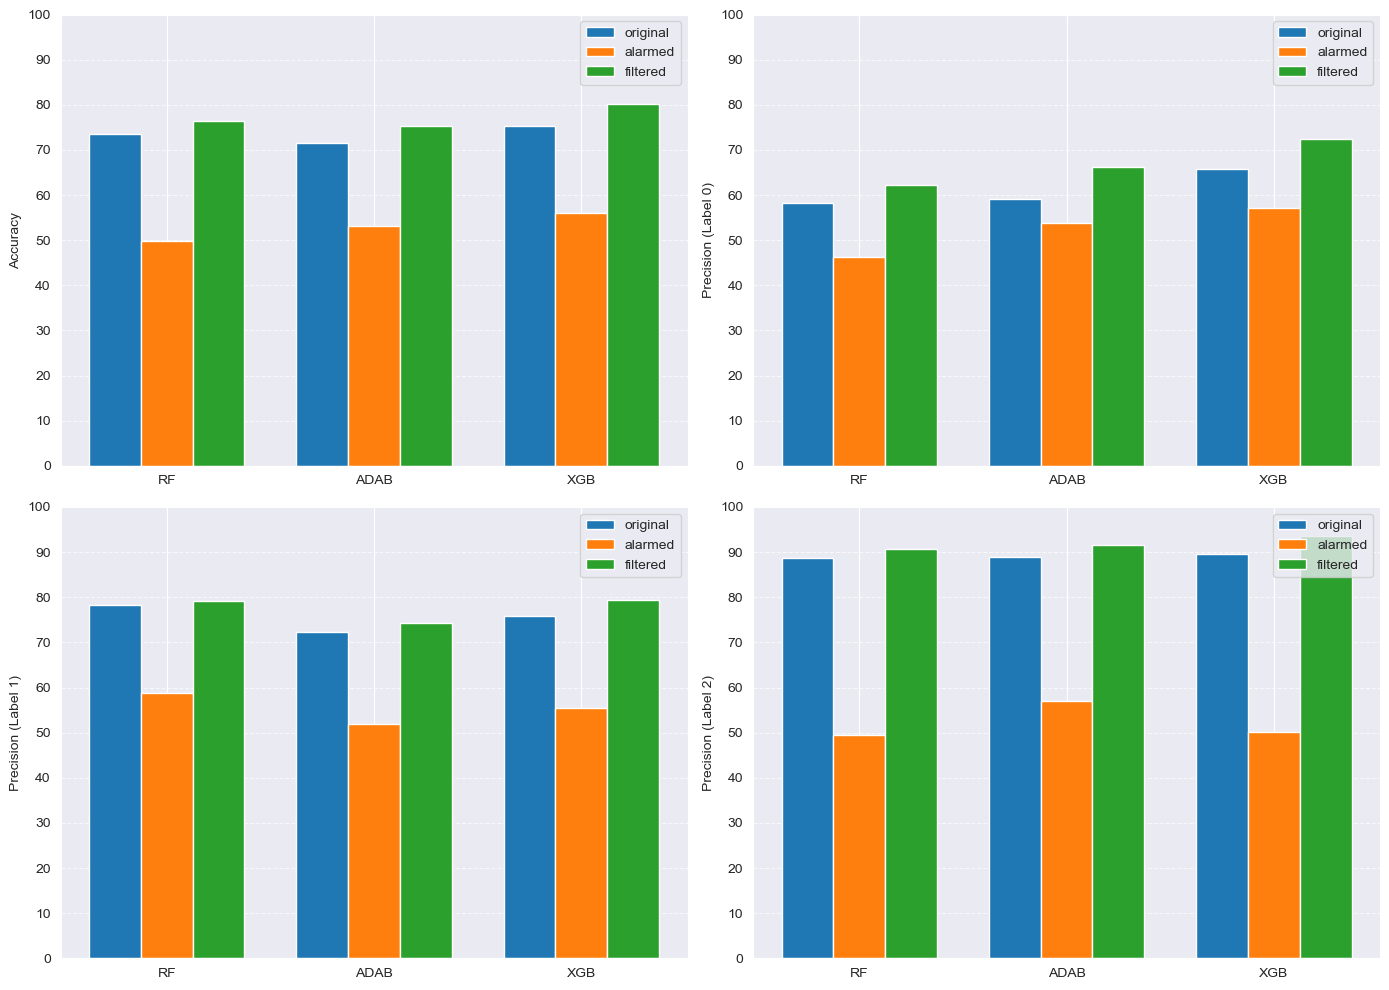

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_metrics(metric_dict):
    models = ["rf", "adab", "xgb"]
    metrics = ["acc", "p0", "p1", "p2"]
    conditions = ["original", "alarmed", "filtered"]
    metric_labels = {
        "acc": "Accuracy",
        "p0": "Precision (Label 0)",
        "p1": "Precision (Label 1)",
        "p2": "Precision (Label 2)"
    }

    # Set up the plot
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Plot each metric
    for i, metric in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        bar_width = 0.25
        index = np.arange(len(models))

        for j, condition in enumerate(conditions):
            values = [metric_dict[model][condition][metric] for model in models]
            ax.bar(index + j * bar_width, values, bar_width, label=condition)

        ax.set_xticks(index + bar_width)
        ax.set_xticklabels([m.upper() for m in models])
        ax.set_ylim(0, 100)  
        ax.set_ylabel(metric_labels[metric]) 
        ax.set_yticks(range(0, 101, 10)) 
        ax.grid(True, axis='y', linestyle='--', alpha=0.7) 
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_grouped_metrics(metric_dict)